# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# **IMPORT DATASET**

In [2]:
path = kagglehub.dataset_download("adityadesai13/used-car-dataset-ford-and-mercedes")
df = pd.read_csv(f"{path}/audi.csv")

Using Colab cache for faster access to the 'used-car-dataset-ford-and-mercedes' dataset.


# **DATA CLEANING**

In [3]:
print(df.head())
print(len(df))

  model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0    A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4
1    A6  2016  16500    Automatic    36203   Diesel   20  64.2         2.0
2    A1  2016  11000       Manual    29946   Petrol   30  55.4         1.4
3    A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0
4    A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0
10668


In [4]:
print(df['model'].value_counts())
print(df['transmission'].value_counts())
print(df['fuelType'].value_counts())

model
A3     1929
Q3     1417
A4     1381
A1     1347
A5      882
Q5      877
Q2      822
A6      748
Q7      397
TT      336
A7      122
A8      118
Q8       69
RS6      39
RS3      33
RS4      31
RS5      29
R8       28
S3       18
SQ5      16
S4       12
SQ7       8
S8        4
S5        3
A2        1
RS7       1
Name: count, dtype: int64
transmission
Manual       4369
Semi-Auto    3591
Automatic    2708
Name: count, dtype: int64
fuelType
Diesel    5577
Petrol    5063
Hybrid      28
Name: count, dtype: int64


categorical features were visualized to assess the cardinality and distribution of the values and do some cleaning

In [5]:
top_10 = df['model'].value_counts().head(10).index
df = df[df['model'].isin(top_10)]
print(len(df))

10136


the dataset was restricted to the ten most common car models, thereby eliminating rare instances (< 300 occurrences).

In [6]:
df=df.dropna()
df=df.drop_duplicates()

missing data and duplicates were discarded to clean the dataset and minimize noise

In [7]:
print(len(df))

10034


post-cleaning, the dataset size is 10,034 rows, more than 600 noisy or irrelevant data points were discarded without losing integrity

# **SCALING AND NORMALIZING**

preprocessing is essential to encode categorical data and normalize numerical features. models require all inputs to be on a comparable scale to learn effectively.

In [8]:
num_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_features = ['model', 'transmission', 'fuelType']

X = df.drop(columns=['price'])
y = df['price']    #price identified as target

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

`StandardScaler` and `OneHotEncoder` were selected to standardize numerical features and encode categorical variables, respectively. these operations were integrated into a single `ColumnTransformer` to create a unified and efficient preprocessing pipeline.

# **DATA SPLIT**

In [9]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

X_train_final = preprocessor.fit_transform(X_train)
X_val_final = preprocessor.transform(X_val)
X_test_final = preprocessor.transform(X_test)

the dataset was partitioned into training (60%), validation (20%), and test (20%) sets prior to dimensionality reduction. this sequence is critical to prevent data leakage, ensuring that the reduction algorithms are fitted exclusively on the training data.

# **DIMENSIONAL REDUCTION**

In [10]:
latent_dim = 8                     #the number of dimensions to which the dataset will be reduced
input_dim = X_train_final.shape[1] #size of the original dataset

**PCA**

In [11]:
pca = PCA(n_components=latent_dim) #pca definition

X_train_pca = pca.fit_transform(X_train_final)
X_val_pca = pca.transform(X_val_final)
X_test_pca = pca.transform(X_test_final)

**AUTOENCODING**

In [12]:
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation='relu')(input_layer)
bottleneck = layers.Dense(latent_dim, activation='linear', name='bottleneck')(encoded)
decoded = layers.Dense(16, activation='relu')(bottleneck)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_final, X_train_final, epochs=50, batch_size=32, validation_data=(X_val_final, X_val_final), verbose=0)

encoder_model = models.Model(input_layer, bottleneck)
X_train_ae = encoder_model.predict(X_train_final)
X_val_ae = encoder_model.predict(X_val_final)
X_test_ae = encoder_model.predict(X_test_final)

201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# **HYPERPARAMETERS SETTING VIA CROSS-VALIDATION**

In [13]:
neuron_options = [32, 64]      #parameters options
lr_options = [0.01, 0.001]
batch_options = [32, 64]
EPOCHS_CV = 20
EPOCHS_FINAL = 100

def grid_search(X_data, y_data, name):
    print(f"\n---Grid Search for: {name} ---")
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    best_mae = float('inf')
    best_params = {}

    total_combinations = len(neuron_options) * len(lr_options) * len(batch_options)
    counter = 0

    for nodes in neuron_options:
        for lr in lr_options:
            for batch in batch_options:
                counter += 1
                fold_maes = []

                for train_idx, val_idx in kf.split(X_data):
                    X_t, X_v = X_data[train_idx], X_data[val_idx]
                    y_t, y_v = y_data.iloc[train_idx], y_data.iloc[val_idx]

                    model = keras.Sequential([
                        layers.Dense(nodes, activation='relu'),
                        layers.Dense(nodes, activation='relu'),
                        layers.Dense(1)
                    ])
                    model.compile(loss='mean_absolute_error',
                                  optimizer=tf.keras.optimizers.Adam(learning_rate=lr))

                    model.fit(X_t, y_t, epochs=EPOCHS_CV, batch_size=batch, verbose=0)
                    mae = model.evaluate(X_v, y_v, verbose=0)
                    fold_maes.append(mae)

                avg_mae = np.mean(fold_maes)

                if avg_mae < best_mae:
                    best_mae = avg_mae
                    best_params = {'nodes': nodes, 'lr': lr, 'batch': batch}

    print(f"Best parameters for {name}: {best_params} (MAE: {best_mae:.2f})")
    return best_params

params_orig = grid_search(X_train_final, y_train, "Original Data")
params_pca = grid_search(X_train_pca, y_train, "PCA Data")
params_ae = grid_search(X_train_ae, y_train, "Autoencoder Data")


---Grid Search for: Original Data ---
Best parameters for Original Data: {'nodes': 64, 'lr': 0.01, 'batch': 32} (MAE: 1825.02)

---Grid Search for: PCA Data ---
Best parameters for PCA Data: {'nodes': 64, 'lr': 0.01, 'batch': 32} (MAE: 2095.87)

---Grid Search for: Autoencoder Data ---
Best parameters for Autoencoder Data: {'nodes': 64, 'lr': 0.01, 'batch': 32} (MAE: 1972.44)


`GridSearch` was employed to identify the optimal hyperparameters via cross-validation for each data representation (Original, PCA, and Autoencoder).

# **FNN (REGRESSION)**

**IMPLEMENTATION**

In [14]:
def model(X_train, y_train, X_val, y_val, params, name):
    print(f"Training {name} with params: {params}...")

    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(params['nodes'], activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        loss='mean_absolute_error',
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['lr']),
        metrics=['mae']
    )

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_FINAL,
        batch_size=params['batch'],
        verbose=0
    )
    end_time = time.time()

    training_duration = end_time - start_time
    print(f"Done! Time taken: {training_duration:.2f} seconds.")  #used for training time comparison

    return model, history, training_duration

we implemented a flexible `Feedforward Neural Network (FNN)` architecture designed to dynamically adapt to the varying input dimensionalities of our experiments (ranging from approximately 40 features for the original dataset to 8 for the reduced versions). the network consists of two hidden layers utilizing `ReLU` activation to capture complex non-linear patterns, followed by a single linear output unit suitable for continuous price regression. furthermore, Mean Absolute Error (MAE) was selected as the loss function to ensure robustness against outliers in the car price distribution.

**IMPLEMENTATION ON ORIGINAL DATASET**

In [15]:
n_opt = params_orig['nodes']
lr_opt = params_orig['lr']
batch_opt = params_orig['batch']

model_orig, history_orig, time_orig = model(
    X_train_final, y_train,
    X_val_final, y_val,
    params_orig,
    "Original Data"
)

Training Original Data with params: {'nodes': 64, 'lr': 0.01, 'batch': 32}...
Done! Time taken: 50.95 seconds.


**IMPLEMENTATION ON PCA REDUCED DATASET**

In [16]:
n_opt = params_pca['nodes']
lr_opt = params_pca['lr']
batch_opt = params_pca['batch']

model_pca, history_pca, time_pca = model(
    X_train_pca, y_train,
    X_val_pca, y_val,
    params_pca,
    "PCA Data"
)

Training PCA Data with params: {'nodes': 64, 'lr': 0.01, 'batch': 32}...
Done! Time taken: 50.43 seconds.


**IMPLEMENTATION ON AUTOENCODE REDUCED DATASET**

In [17]:
n_opt = params_ae['nodes']
lr_opt = params_ae['lr']
batch_opt = params_ae['batch']

model_ae, history_ae, time_ae = model(
    X_train_ae, y_train,
    X_val_ae, y_val,
    params_ae,
    "Autoencoder Data"
)

Training Autoencoder Data with params: {'nodes': 64, 'lr': 0.01, 'batch': 32}...
Done! Time taken: 50.66 seconds.


# **RESULT COMPARISON**

In [18]:
def get_metrics_and_time(model, X_test, y_test, train_time, name):
    t0 = time.time()
    predictions = model.predict(X_test, verbose=0).flatten()
    inference_time = time.time() - t0

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'Training Time (s)': train_time,
        'Inference Time (s)': inference_time,
        'Predictions': predictions
    }


In [19]:
metrics_orig = get_metrics_and_time(model_orig, X_test_final, y_test, time_orig, "Original")
metrics_pca = get_metrics_and_time(model_pca, X_test_pca, y_test, time_pca, "PCA")
metrics_ae = get_metrics_and_time(model_ae, X_test_ae, y_test, time_ae, "Autoencoder")

results_df = pd.DataFrame([
    {k: v for k, v in metrics_orig.items() if k != 'Predictions'},
    {k: v for k, v in metrics_pca.items() if k != 'Predictions'},
    {k: v for k, v in metrics_ae.items() if k != 'Predictions'}
])

print("                            FINAL COMPARATIVE ANALYSIS")

display(results_df.round(4))


                            FINAL COMPARATIVE ANALYSIS


,Model,MAE,RMSE,R2 Score,Training Time (s),Inference Time (s)
0,Original,1843.7263,2774.4713,0.9169,50.9466,0.2098
1,PCA,2182.3374,3235.7939,0.8869,50.4268,0.2205
2,Autoencoder,2066.9546,3445.5875,0.8718,50.6584,0.1964


/tmp/ipython-input-2397327812.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Training Time (s)', data=results_df, palette='viridis', ax=ax1)


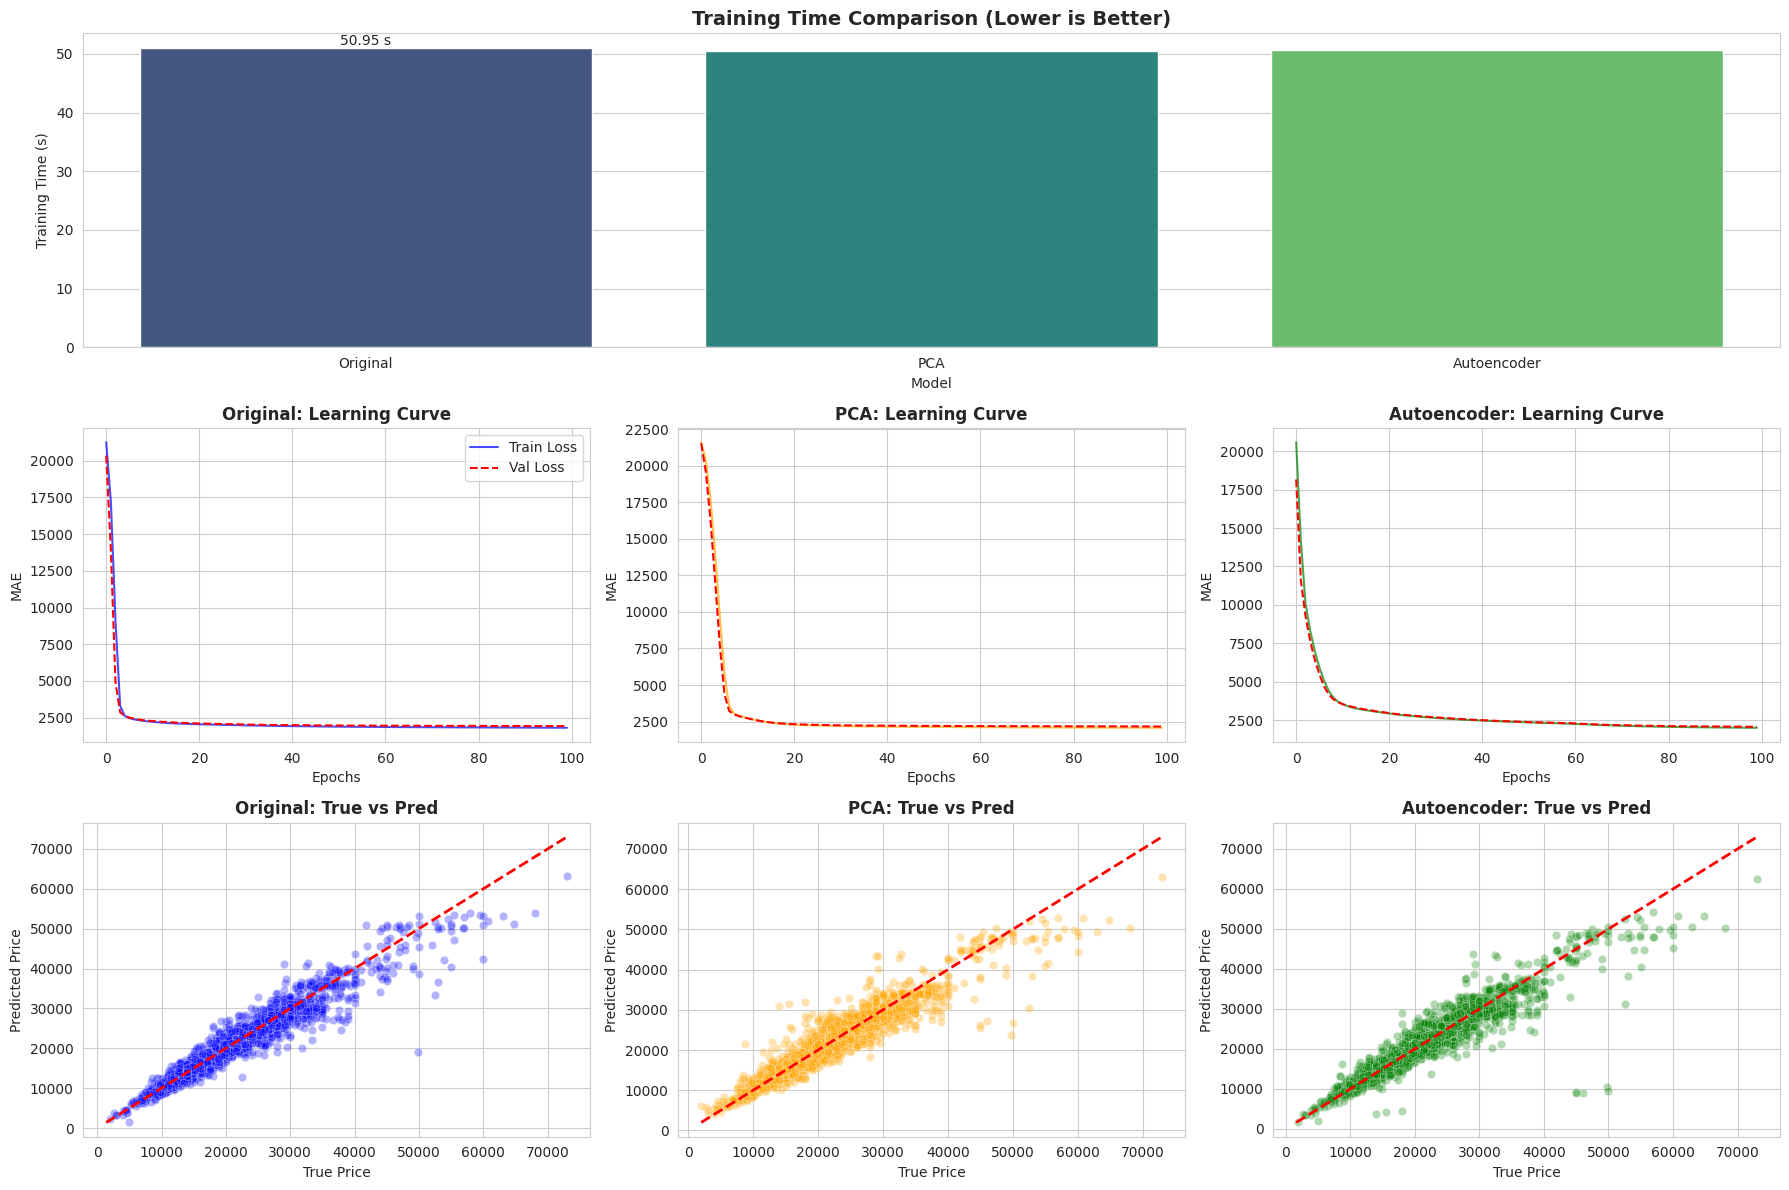

In [20]:
sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, :])
sns.barplot(x='Model', y='Training Time (s)', data=results_df, palette='viridis', ax=ax1)
ax1.set_title('Training Time Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax1.bar_label(ax1.containers[0], fmt='%.2f s')

histories = [history_orig, history_pca, history_ae]
titles = ["Original", "PCA", "Autoencoder"]
colors = ['blue', 'orange', 'green']

for i, (history, title, color) in enumerate(zip(histories, titles, colors)):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(history.history['loss'], label='Train Loss', color=color, alpha=0.7)
    ax.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
    ax.set_title(f'{title}: Learning Curve', fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('MAE')
    if i == 0: ax.legend()

predictions_list = [metrics_orig['Predictions'], metrics_pca['Predictions'], metrics_ae['Predictions']]

for i, (preds, title, color) in enumerate(zip(predictions_list, titles, colors)):
    ax = fig.add_subplot(gs[2, i])
    sns.scatterplot(x=y_test, y=preds, alpha=0.3, color=color, ax=ax)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_title(f'{title}: True vs Pred', fontweight='bold')
    ax.set_xlabel('True Price')
    ax.set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()